# Monte Carlo BB light curve study

In [1]:
%reset -f
%run pylib/setup dark
from pylib import data_setup
from importlib import reload
from pylib import mc_dev; reload(mc_dev)
from pylib.mc_dev import (sim_design_thoughts, check_step, BBsim, p_view, show, show_date,
                          capture_hide, plt, sns, pd, np)
from wtlike import WtLike, Timer
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-07-23 08:18</h5>

In [2]:
# show(sim_design_thoughts, summary='Simulation design')
name = '4FGL J0056.3-0935' # strong single-step
show(f"""Choose {name} to use for MC study""")
with capture_hide(f'Source setup output for {name}') as printout:
    wtl = WtLike(name, time_bins=(0,0,30),clear=False)
show(printout)
show(f'Will use its `{len(wtl.photons)}` weight values for simulation') 

Choose 4FGL J0056.3-0935 to use for MC study

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f4e6660>

Will use its `85266` weight values for simulation

## BB with data

Bayesian Blocks: partitioning 218  cells using LikelihoodFitness with penalty 5%
	found 2 / 218 blocks.
LightCurve: Loaded 2 / 2 cells for fitting


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f3127b0>
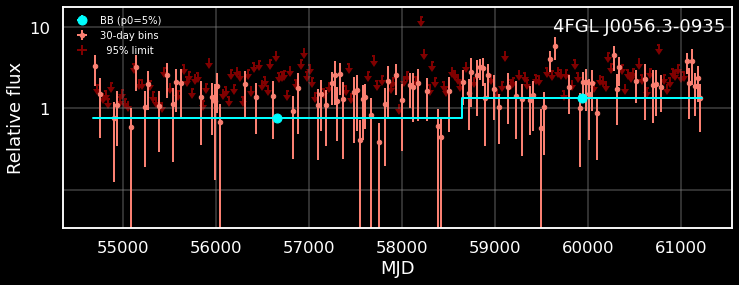

TSvar = 24.8 for 2 blocks

Single step observed at MJD 58643.0, 
ratio 1.75

In [3]:
show(f"""## BB with data""")
bb_full = wtl.bb_view()
bb_full.plot(log=True);
show(plt.gcf())

step = check_step(bb_full)
# bb_full_r = wtl.bb_view(reverse=True)
# check_step(bb_full_r)

# Create partitions 

LightCurve: Loaded 102 / 102 cells for fitting
Bayesian Blocks: partitioning 102 reversed cells using LikelihoodFitness with penalty 5%
	found 2 / 102 blocks.
LightCurve: Loaded 2 / 2 cells for fitting


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f312f90>
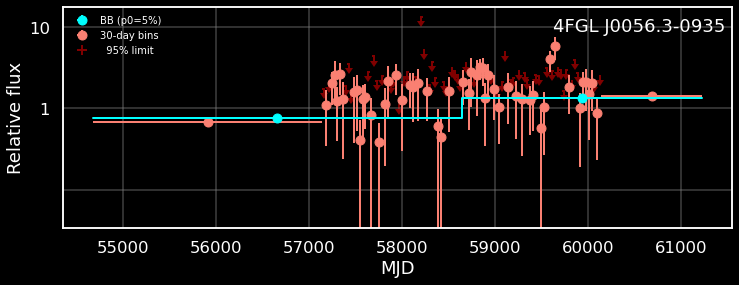

TSvar = 24.8 for 2 blocks

Single step observed at MJD 58643.0, 
ratio 1.75

### Set partition to expand times [np.float64(57143.0), np.float64(60143.0)]

In [4]:
show(f"""# Create partitions """)
delta = 1500
trange=[step.time-delta,step.time+delta]
partition_view = p_view(wtl, *trange)# pedges)
bbv = partition_view.bb_view(reverse=True)
bbv.plot(log=True)#, xlim=(56900,57500)); 
show(plt.gcf())

step = check_step(bbv)
show(f"""### Set partition to expand times {trange}""")
first = partition_view.cells.iloc[0]
last  = partition_view.cells.iloc[-1]
full = pd.Series(wtl.concatenate())

# Run BBsim

In [5]:
reload (mc_dev); from pylib.mc_dev import BBsim
show_date()
show(f"""### Run the simulation {(N:=10000) } times on {(nproc:=8)} processors. """)
bbs, df_all = BBsim.run_many(partition_view,  seeds=range(N), nproc=nproc,
                             step_time=step.time,#+15,
                             cache='files/bbsim/cache_00.pkl')
# show(et)
df_all.head()

<h5 style="text-align:right; margin-right:15px"> 2026-07-23 08:19</h5>

### Run the simulation 10000 times on 8 processors. 

### Setup BB fit sims with cell partitioning
Assume step at 58643.0 

* Loading cached results from `files/bbsim/cache_00.pkl`, last modified: 2026-07-22 14:30:26

,time,ts,ratio,nbb,gap
0,58313.0,44.2,2.10,2,0.0
1,58643.0,46.3,2.15,2,0.0
2,58493.0,60.9,2.45,2,0.0
3,58673.0,54.1,2.33,2,0.0
4,58958.0,67.5,2.21,4,570.0


## Plots of the results

Number of blocks <br>
         

,2,3,4
instances,9735,214,51


Selecting nbb==2

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f312ba0>
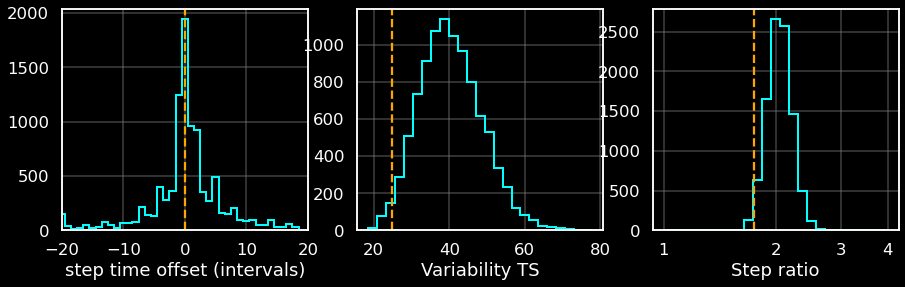

In [6]:
reload (mc_dev); from pylib.mc_dev import BBsim_plots
simplots = BBsim_plots(bbs, df_all, step, interval=40)
simplots.hists(dtmax=20)

Selecting nbb>2

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f312ba0>
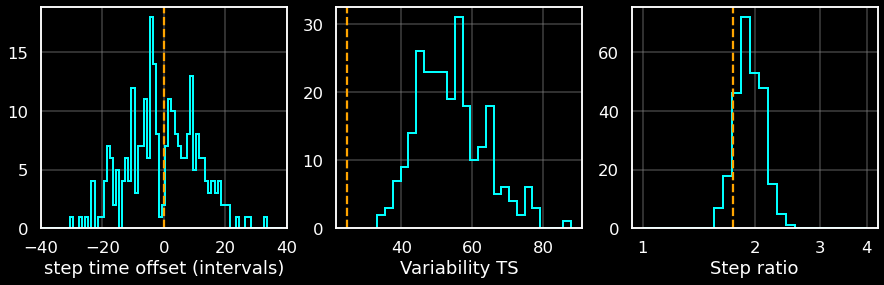

In [7]:
simplots.hists('nbb>2')

### Corner pairplot

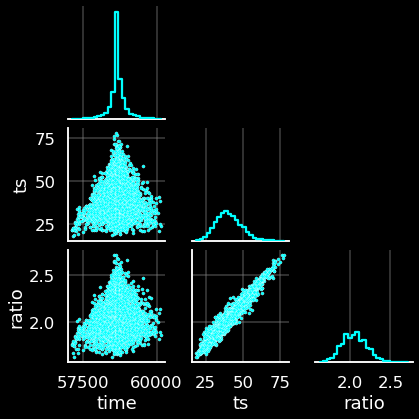

In [8]:
show('### Corner pairplot')
df2 = df_all.query('nbb==2')
sns.pairplot(df2.drop(['nbb','gap'],axis=1), height=2,corner=True,
             diag_kws=dict(bins=25, element='step',fill=False, color='cyan'),
             plot_kws=dict(s=10, color='cyan'),
        );

### Examine the first 10 nbb==3 cases 

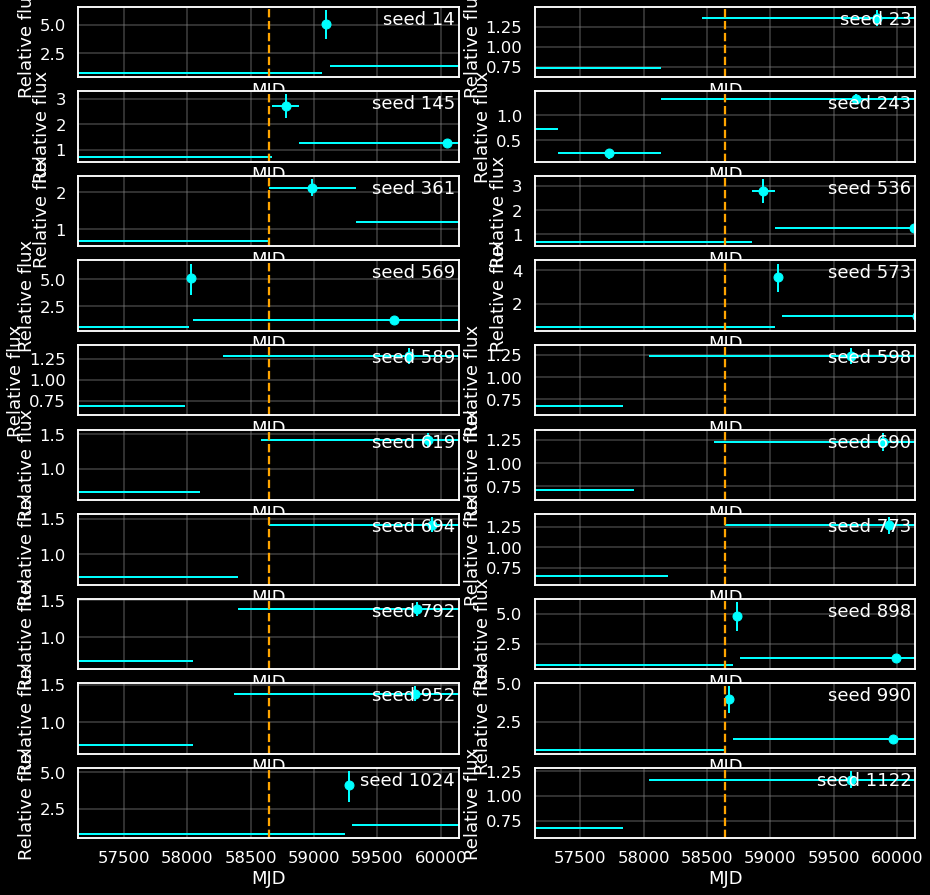

In [9]:
show(f"""### Examine the first 10 nbb==3 cases """)
from wtlike.lightcurve import flux_plot
fig, axx = plt.subplots(nrows=10, ncols=2, figsize=(15,15),sharex=True)#,sharey=True)
for seed, ax in zip(df_all.query('nbb==3').index[:20], axx.flat):
    with capture_hide():
        bv =bbs.sim_view(step_time=None, seed=seed).bb_view()
        y = list(bv.fits.fit.apply(lambda fit: fit.flux)) # flux values from the fits

    #ax.axvspan(*trange,  color='0.2')
    flux_plot(bv.fits, ax=ax, source_name=f'seed {seed}',
            colors='cyan none none'.split(), log=False);
    ax.get_legend().remove()
    ax.axvline(step.time, color='orange',ls='--')   
    ax.set(xlim=(trange))# ylim=(y[0], y[-1]))


In [10]:
y = bv.fits.fit.apply(lambda fit: fit.flux) # flux values from the fits

### Examine the nbb==4 cases 

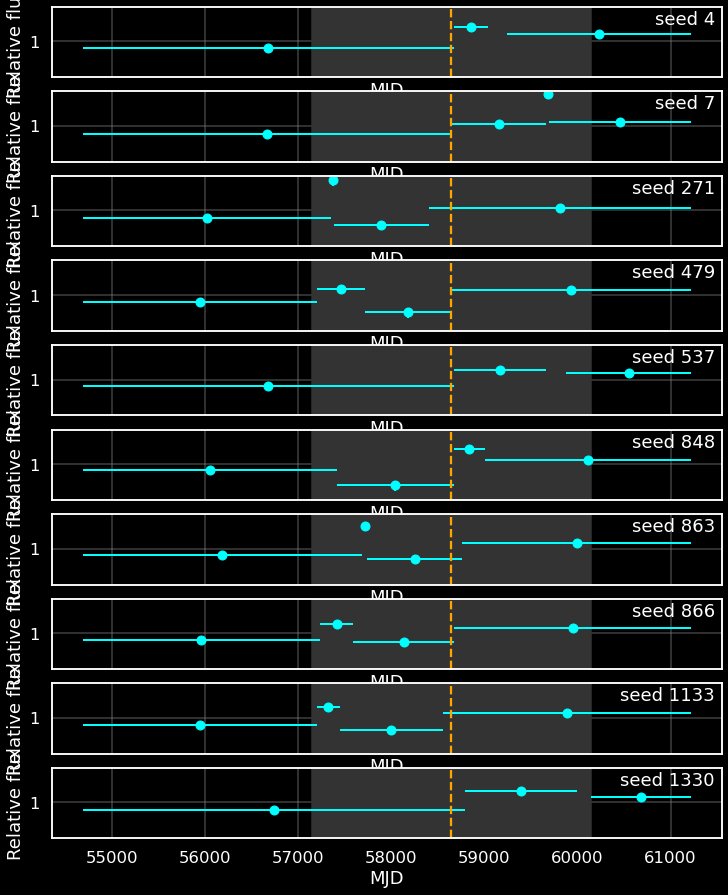

In [11]:
show(f"""### Examine the nbb==4 cases """)
from wtlike.lightcurve import flux_plot
fig, axx = plt.subplots(nrows=10, figsize=(12,15),sharex=True,sharey=True)
for seed, ax in zip(df_all.query('nbb==4').index, axx.flat):
    with capture_hide():
        bv =bbs.sim_view(step_time=None, seed=seed).bb_view()

    ax.axvspan(*trange,  color='0.2')
    flux_plot(bv.fits, ax=ax, source_name=f'seed {seed}',
              colors='cyan none none'.split(),log=True);
    ax.get_legend().remove()
    ax.axvline(step.time, color='orange',ls='--')


In [12]:
show(f""" ## Define and study the "gap" """)
t = bbs.sim_view(step_time=None, seed=441).bb_view()

## Define and study the "gap" 

Bayesian Blocks: partitioning 102  cells using LikelihoodFitness with penalty 5%
	found 2 / 102 blocks.
LightCurve: Loaded 2 / 2 cells for fitting


In [13]:
reload (mc_dev); from pylib.mc_dev import check_step
check_step(t)

TSvar = 31.7 for 2 blocks

Single step observed at MJD 58373.0, 
ratio 1.90

StepInfo(time=np.float64(58373.0), ts=np.float64(31.7), ratio=np.float64(1.9), nbb=2, gap=0)

---
# Tests and demos

## Demonstrate `CellSim` weight generation

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f312a50>
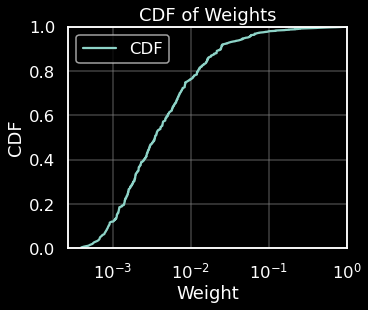

| Sample  | N | $<w>$ | $<w^2>$ | $\alpha$ | $\sigma_\alpha$
| --------|--:|------:|--------:|---------:|-----------
|data     | 85,027|1.50e-02| 3.79e-03|-0.003 | 0.056
|uniform  | 85,027|1.50e-02| 3.79e-03|-0.003 | 0.056
|random   | 85,027|1.52e-02| 3.93e-03|0.042 | 0.055

In [14]:
from pylib.mc_dev import CellSim
show(f"""## Demonstrate `CellSim` weight generation""")
show(CellSim.plot_cdf(full))
show(CellSim.check_weights(full)     )   
        

## Select a 1-week cell for sampling
Use CellSim to generate 100 trials

The sammple:
 t                                               59933.0
tw                                               2580.0
e                                           1516.311768
n                                                 34291
S                                            505.969811
B                                             33142.143
w     [0.005695343, 0.002275467, 0.006298065, 0.0008...
Name: 1, dtype: object


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f3123c0>
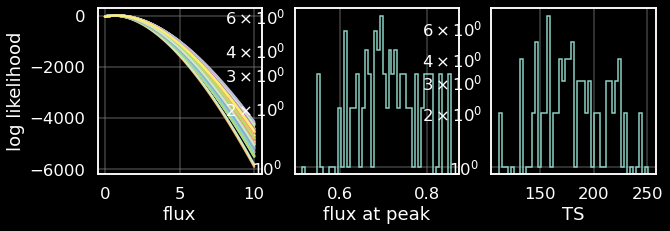

## Combine 100 simulated likelihoods
1. Using table lookup scheme with 1000 points.<br>
This is what is done by the BB algorithm.
2. Combine the cells

CPU times: user 65.5 ms, sys: 193 μs, total: 65.7 ms
Wall time: 67.2 ms


0.688[1+0.012-0.012], < 0.70

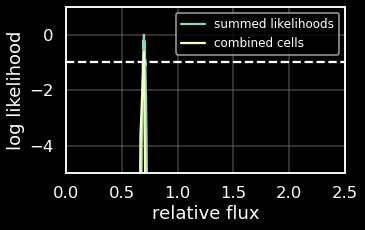

In [15]:

show(f"""## Select a 1-week cell for sampling
Use CellSim to generate {(N:=100)} trials""")
from wtlike.loglike import LogLike, PoissonRep
sample_cell = bb_full.cells.iloc[1]
print('The sammple:\n',sample_cell)
csim = CellSim(first)
trial_cells = pd.DataFrame([csim(sample_cell) for i in range(N)])

pp = [PoissonRep(LogLike(csim(trial_cells.iloc[i]))) for i in range(N)]

fig, (ax3,ax1,ax2) = plt.subplots(ncols=3, figsize=(10,3))
ax1.hist([x.flux for x in pp], bins=50, histtype='step')
ax1.set(xlabel='flux at peak',yscale='log')
ax2.hist([x.ts for x in pp], bins=50, histtype='step')
ax2.set(xlabel='TS',yscale='log')


x = np.linspace(0,10,100);
for f in pp[:100]:
    ax3.plot(x, f(x));
ax3.set(xlabel='flux',ylabel='log likelihood');
show(fig)


show(f"""## Combine {len(pp)} simulated likelihoods
1. Using table lookup scheme with {(npt:=1000)} points.<br>
This is what is done by the BB algorithm.
2. Combine the cells""")
R=len(pp)-1
%time tables = list(map(lambda p: p.create_table(npt), pp))
a, y = tables[R]
x = np.linspace(*a)
y = np.zeros(npt)
rv = np.empty(R+1)
for i in range(R,-1,-1):
    a, yi = tables[i]
    xi = np.linspace(*a)
    y += np.interp(x, xi, yi, left=-np.inf, right=-np.inf)
    amax = np.argmax(y)
    rv[i] = y[amax]

plt.plot(x,y-np.max(y), label='summed likelihoods'); 

def concat(pcells,):
    newcell = dict()
    for col in 'n S B'.split():
        newcell[col] = pcells[col].sum()
    newcell['w'] = np.concatenate(pcells.w.values)
    return newcell
pr = PoissonRep(LogLike(concat(trial_cells)))
show(str(pr))
plt.plot((x:=np.linspace(0,3,100)), pr(x), label='combined cells');
plt.gca().set(xlim=(0.,2.5), ylim = (-5,1), ylabel='log likelihood', xlabel='relative flux');
plt.axhline(-1, ls='--')
plt.legend(fontsize=12); plt.show()

In [16]:
show(f"""## Simulate the large cells, to check errors
With {(N:=4000)} trials each.""")
cells = (first, last, full)
from multiprocessing import Pool

def run_sim(i):
    cell = cells[i]
    return  np.array([PoissonRep(LogLike(CellSim(cell)(cell,inplace=False))).flux for k in range(N)])

with Timer() as et:
    with Pool(len(cells)) as pool:
        fluxes = pool.map(run_sim, range(len(cells)))
show(et)

## Simulate the large cells, to check errors
With 4000 trials each.

elapsed time: 44.4s (0.7 min)

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f311010>
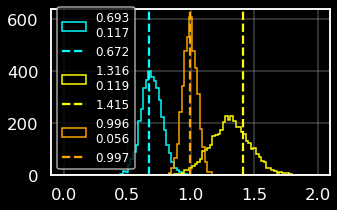

In [17]:
hkw = dict(bins=np.linspace(0,2,100), histtype='step')
fig, ax = plt.subplots(figsize=(5,3))
for fx, color, cell in zip( fluxes, 'cyan yellow orange'.split(), cells):
    ax.hist(fx,**hkw, label=f"{fx.mean():.3f}\n{fx.std()/fx.mean():.3f}", color=color);
    ax.axvline((genf:=CellSim(cell).flux), ls='--', color=color, label=f'{genf:.3f}')

ax.legend(fontsize=12);
show(fig)

In [18]:
from wtlike import check_data
check_data(update=False)
show_date()

Weekly folder "/mnt/c/Users/thbur/onedrive/fermi/wtlike-data/data_files" contains 937 weeks.
	 Last week in local dataset, #946, has 4.583 days, ends at UTC 2026-07-20 14:41, filedate 20260720171655
Weeks needing download: [np.int64(946), 947]


<h5 style="text-align:right; margin-right:15px"> 2026-07-23 08:19</h5>